In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from scipy.stats import linregress

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [7]:
nav_history = pd.read_csv("../data/processed/nav_history_cleaned.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

performance = pd.read_csv("../data/processed/scheme_performance_cleaned.csv")

print(nav_history.shape)
print(benchmark.shape)
print(performance.shape)

(46000, 3)
(8050, 3)
(40, 19)


In [3]:
nav_history['date'] = pd.to_datetime(nav_history['date'])

benchmark['date'] = pd.to_datetime(benchmark['date'])

print("Date conversion completed")

Date conversion completed


In [4]:
nav_history = nav_history.sort_values(
    ['amfi_code','date']
)

nav_history['daily_return'] = (
    nav_history.groupby('amfi_code')['nav']
    .pct_change()
)

nav_history.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


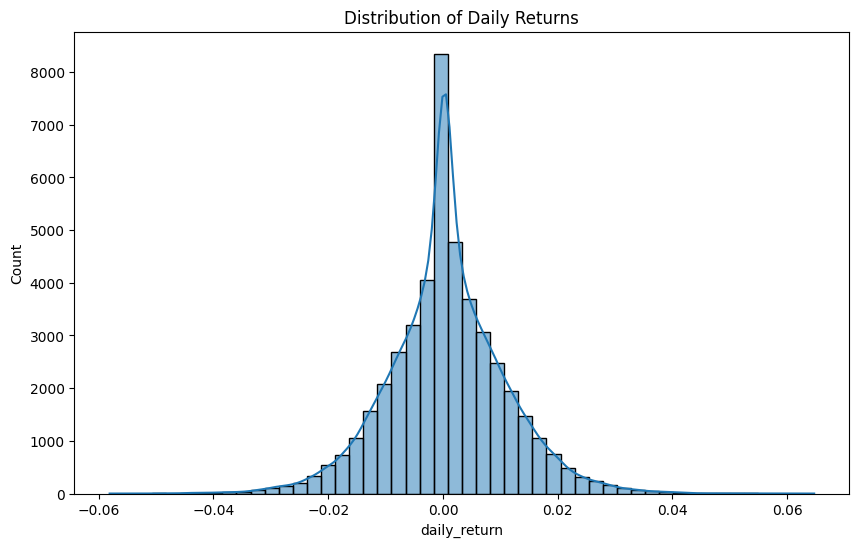

In [5]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav_history['daily_return'].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.show()

### Finding 1

Daily fund returns are concentrated around zero with occasional extreme movements, indicating normal market volatility patterns.

In [8]:
print(nav_history['date'].min())
print(nav_history['date'].max())

2022-01-03
2026-05-29


In [10]:
print(nav_history.dtypes)

amfi_code      int64
date          object
nav          float64
dtype: object


In [11]:
nav_history['date'] = pd.to_datetime(nav_history['date'])

print(nav_history['date'].dtype)

datetime64[ns]


In [12]:
cagr_results = []

latest_date = nav_history['date'].max()

for fund in nav_history['amfi_code'].unique():

    fund_data = nav_history[
        nav_history['amfi_code'] == fund
    ].sort_values('date')

    latest_nav = fund_data.iloc[-1]['nav']

    result = {'amfi_code': fund}

    # 1 Year CAGR
    target_date_1y = latest_date - pd.DateOffset(years=1)

    data_1y = fund_data[fund_data['date'] >= target_date_1y]

    if len(data_1y) > 1:
        start_nav = data_1y.iloc[0]['nav']
        cagr_1y = ((latest_nav / start_nav) ** (1/1) - 1) * 100
        result['CAGR_1Y'] = round(cagr_1y, 2)
    else:
        result['CAGR_1Y'] = np.nan

    # 3 Year CAGR
    target_date_3y = latest_date - pd.DateOffset(years=3)

    data_3y = fund_data[fund_data['date'] >= target_date_3y]

    if len(data_3y) > 1:
        start_nav = data_3y.iloc[0]['nav']
        cagr_3y = ((latest_nav / start_nav) ** (1/3) - 1) * 100
        result['CAGR_3Y'] = round(cagr_3y, 2)
    else:
        result['CAGR_3Y'] = np.nan

    cagr_results.append(result)

cagr_df = pd.DataFrame(cagr_results)

print(cagr_df.head())

   amfi_code  CAGR_1Y  CAGR_3Y
0     100016    -2.22     1.29
1     100025     3.70     3.92
2     100033    53.23    32.44
3     101206    47.92    28.97
4     101207   -23.99    -4.15


In [13]:
top10_cagr = cagr_df.sort_values(
    by='CAGR_3Y',
    ascending=False
).head(10)

print(top10_cagr)

    amfi_code  CAGR_1Y  CAGR_3Y
16     119094    22.26    35.11
34     148567    20.36    34.00
24     120504    13.06    32.49
2      100033    53.23    32.44
25     120505    29.60    31.78
19     119551    60.44    30.46
30     120843    26.66    29.58
36     148569    39.75    29.18
3      101206    47.92    28.97
39     149324    65.14    27.00


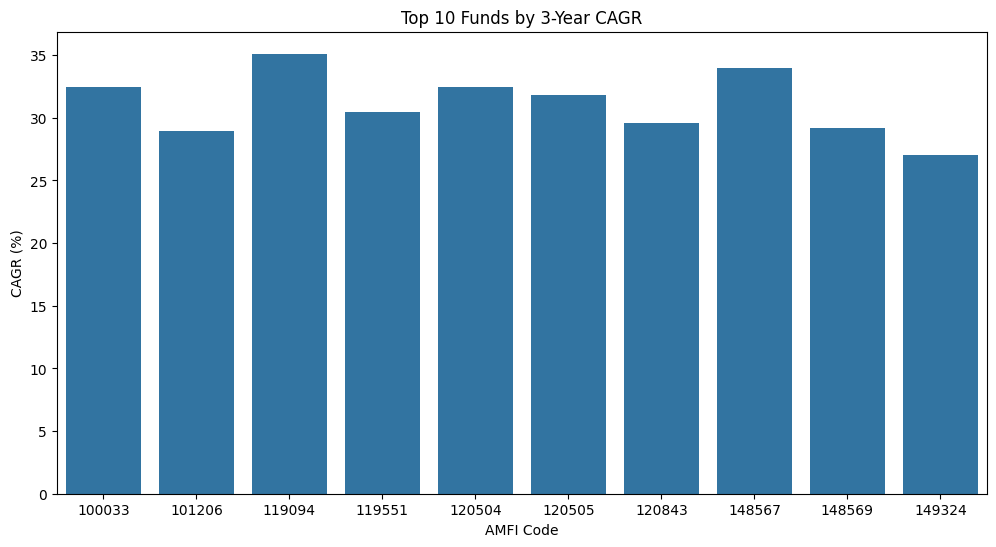

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_cagr,
    x='amfi_code',
    y='CAGR_3Y'
)

plt.title("Top 10 Funds by 3-Year CAGR")
plt.xlabel("AMFI Code")
plt.ylabel("CAGR (%)")

plt.show()

### Finding 2

The best-performing mutual funds delivered significantly higher 3-year CAGR values, indicating strong long-term wealth creation potential compared with lower-ranked schemes.

In [16]:
nav_history['daily_return'] = (
    nav_history.groupby('amfi_code')['nav']
    .pct_change()
)

nav_history.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [17]:
import numpy as np

RISK_FREE_RATE = 0.065

sharpe_results = []

for fund in nav_history['amfi_code'].unique():

    fund_returns = nav_history[
        nav_history['amfi_code'] == fund
    ]['daily_return'].dropna()

    if len(fund_returns) > 0:

        annual_return = fund_returns.mean() * 252
        annual_volatility = fund_returns.std() * np.sqrt(252)

        sharpe_ratio = (
            (annual_return - RISK_FREE_RATE)
            / annual_volatility
        )

        sharpe_results.append([
            fund,
            round(sharpe_ratio, 4)
        ])

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=['amfi_code', 'sharpe_ratio']
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.2015
1,100025,-0.5671
2,100033,1.0937
3,101206,1.0272
4,101207,0.1627


In [18]:
top_sharpe = sharpe_df.sort_values(
    by='sharpe_ratio',
    ascending=False
).head(10)

print(top_sharpe)

    amfi_code  sharpe_ratio
34     148567        1.4483
30     120843        1.3067
36     148569        1.2349
19     119551        1.2083
25     120505        1.1801
38     149323        1.1321
2      100033        1.0937
9      118632        1.0817
3      101206        1.0272
24     120504        1.0265


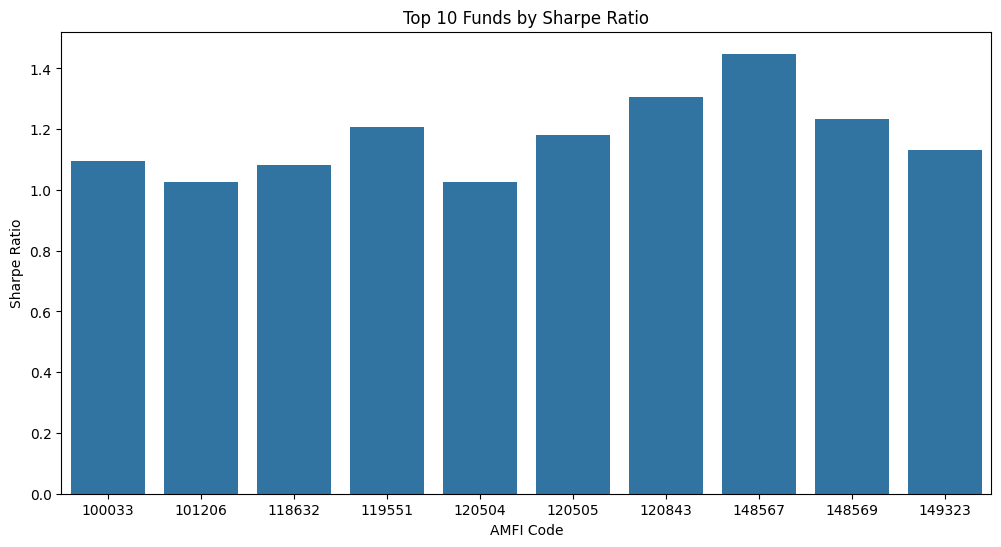

In [19]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_sharpe,
    x='amfi_code',
    y='sharpe_ratio'
)

plt.title("Top 10 Funds by Sharpe Ratio")
plt.xlabel("AMFI Code")
plt.ylabel("Sharpe Ratio")

plt.show()

### Finding 3

Funds with higher Sharpe Ratios generated better risk-adjusted returns, indicating more efficient performance relative to the volatility experienced by investors.

In [21]:
import numpy as np

RISK_FREE_RATE = 0.065

sortino_results = []

for fund in nav_history['amfi_code'].unique():

    fund_returns = nav_history[
        nav_history['amfi_code'] == fund
    ]['daily_return'].dropna()

    if len(fund_returns) > 0:

        annual_return = fund_returns.mean() * 252

        downside_returns = fund_returns[
            fund_returns < 0
        ]

        downside_std = (
            downside_returns.std()
            * np.sqrt(252)
        )

        if downside_std != 0:

            sortino_ratio = (
                (annual_return - RISK_FREE_RATE)
                / downside_std
            )

        else:
            sortino_ratio = np.nan

        sortino_results.append([
            fund,
            round(sortino_ratio, 4)
        ])

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        'amfi_code',
        'sortino_ratio'
    ]
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.3510
1,100025,-0.9418
2,100033,1.8291
3,101206,1.7996
4,101207,0.2766


In [23]:
top_sortino = sortino_df.sort_values(
    by='sortino_ratio',
    ascending=False
).head(10)

print(top_sortino)

    amfi_code  sortino_ratio
34     148567         2.3856
30     120843         2.3643
36     148569         2.1469
19     119551         2.1403
25     120505         2.0294
38     149323         1.8751
9      118632         1.8501
2      100033         1.8291
24     120504         1.8053
3      101206         1.7996


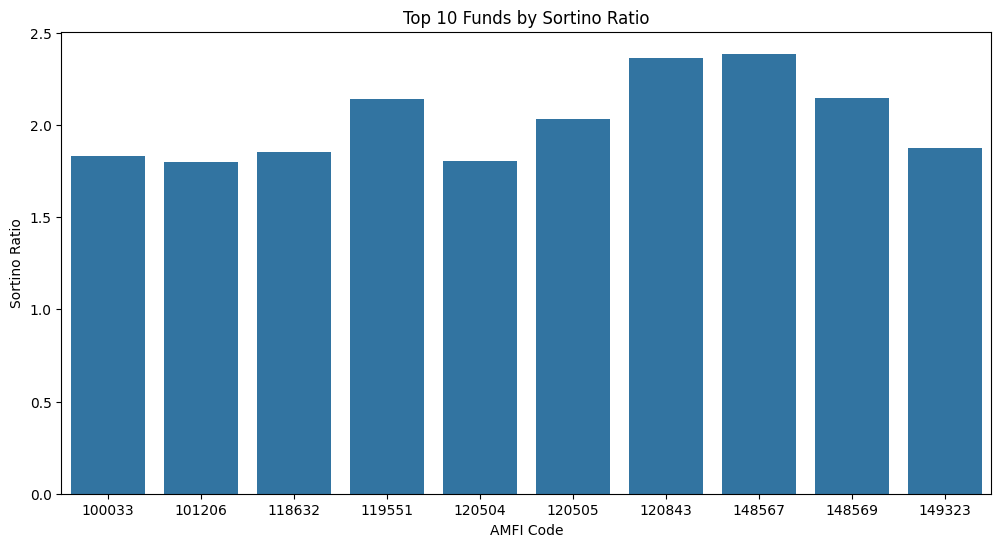

In [24]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_sortino,
    x='amfi_code',
    y='sortino_ratio'
)

plt.title("Top 10 Funds by Sortino Ratio")
plt.xlabel("AMFI Code")
plt.ylabel("Sortino Ratio")

plt.show()

### Finding 4

Funds with higher Sortino Ratios delivered superior downside risk-adjusted returns, indicating better protection against negative market movements.

In [26]:
print(benchmark.columns.tolist())
print(benchmark.head())

['date', 'index_name', 'close_value']
         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15


In [27]:
print(benchmark['index_name'].unique())

['NIFTY50' 'NIFTY100' 'NIFTY_MIDCAP150' 'BSE_SMALLCAP' 'NIFTY500'
 'CRISIL_LIQUID' 'CRISIL_GILT']


In [28]:
# Date convert
benchmark['date'] = pd.to_datetime(benchmark['date'])

# Sirf NIFTY100
nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

# Daily returns
nifty100['benchmark_return'] = (
    nifty100['close_value']
    .pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [29]:
from scipy.stats import linregress

alpha_beta_results = []

for fund in nav_history['amfi_code'].unique():

    fund_data = nav_history[
        nav_history['amfi_code'] == fund
    ][['date', 'daily_return']].copy()

    merged = pd.merge(
        fund_data,
        nifty100[['date', 'benchmark_return']],
        on='date',
        how='inner'
    ).dropna()

    if len(merged) > 30:

        regression = linregress(
            merged['benchmark_return'],
            merged['daily_return']
        )

        beta = regression.slope

        alpha = regression.intercept * 252

        alpha_beta_results.append([
            fund,
            round(alpha, 6),
            round(beta, 4)
        ])

alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        'amfi_code',
        'alpha',
        'beta'
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.0583
1,100025,0.042818,0.0012
2,100033,0.271954,0.0051
3,101206,0.213998,0.0211
4,101207,0.108971,-0.0653


In [30]:
top_alpha = alpha_beta_df.sort_values(
    by='alpha',
    ascending=False
).head(10)

print(top_alpha)

    amfi_code     alpha    beta
21     119598  0.303370 -0.0232
39     149324  0.300579  0.0115
25     120505  0.292636  0.0005
36     148569  0.282704  0.0181
30     120843  0.273305 -0.0228
2      100033  0.271954  0.0051
34     148567  0.269838  0.0237
38     149323  0.265986 -0.0025
16     119094  0.260767 -0.0663
19     119551  0.232010 -0.0318


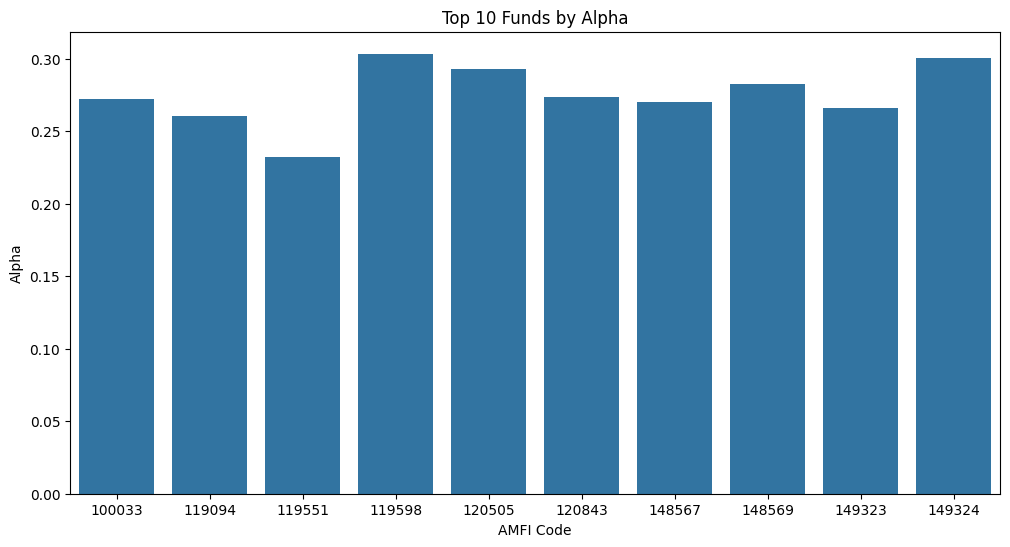

In [31]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_alpha,
    x='amfi_code',
    y='alpha'
)

plt.title("Top 10 Funds by Alpha")
plt.xlabel("AMFI Code")
plt.ylabel("Alpha")

plt.show()

In [32]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved successfully")

alpha_beta.csv saved successfully


### Finding 5

Funds with positive alpha outperformed the benchmark on a risk-adjusted basis, while beta values indicated varying levels of market sensitivity across schemes.

In [33]:
mdd_results = []

for fund in nav_history['amfi_code'].unique():

    fund_data = nav_history[
        nav_history['amfi_code'] == fund
    ].sort_values('date').copy()

    # Running max NAV
    fund_data['running_max'] = (
        fund_data['nav'].cummax()
    )

    # Drawdown
    fund_data['drawdown'] = (
        fund_data['nav']
        / fund_data['running_max']
    ) - 1

    max_drawdown = fund_data['drawdown'].min()

    mdd_results.append([
        fund,
        round(max_drawdown * 100, 2)
    ])

mdd_df = pd.DataFrame(
    mdd_results,
    columns=[
        'amfi_code',
        'max_drawdown_pct'
    ]
)

mdd_df.head()

,amfi_code,max_drawdown_pct
0,100016,-24.73
1,100025,-4.31
2,100033,-16.22
3,101206,-11.29
4,101207,-35.45


In [34]:
worst_mdd = mdd_df.sort_values(
    by='max_drawdown_pct'
).head(10)

print(worst_mdd)

    amfi_code  max_drawdown_pct
22     119599            -52.57
17     119095            -51.68
4      101207            -35.45
39     149324            -31.17
21     119598            -28.71
7      102886            -28.00
0      100016            -24.73
29     120842            -24.00
11     118634            -23.34
15     119093            -21.75


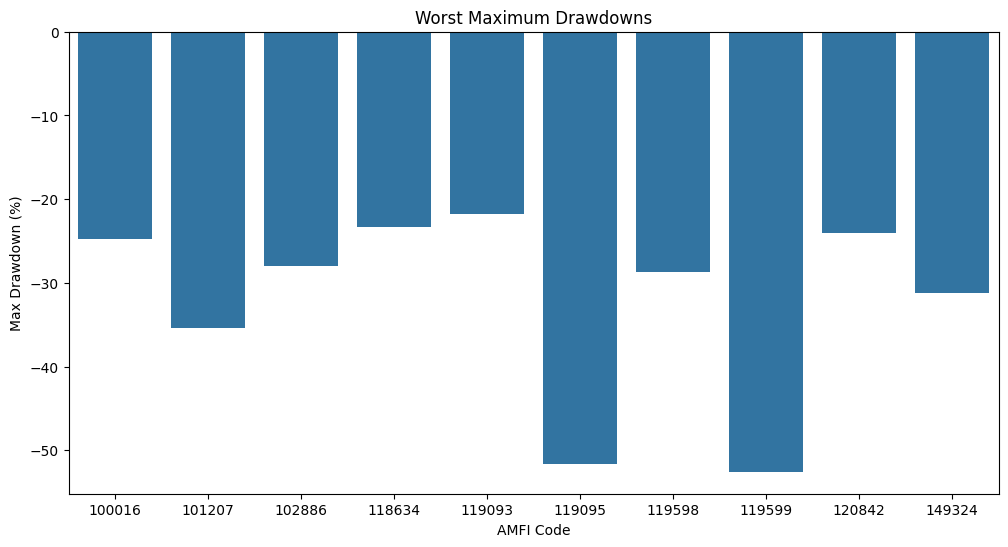

In [35]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=worst_mdd,
    x='amfi_code',
    y='max_drawdown_pct'
)

plt.title("Worst Maximum Drawdowns")
plt.xlabel("AMFI Code")
plt.ylabel("Max Drawdown (%)")

plt.show()

In [36]:
worst_fund = mdd_df.sort_values(
    by='max_drawdown_pct'
).iloc[0]['amfi_code']

fund_data = nav_history[
    nav_history['amfi_code'] == worst_fund
].sort_values('date').copy()

fund_data['running_max'] = fund_data['nav'].cummax()

fund_data['drawdown'] = (
    fund_data['nav']
    / fund_data['running_max']
) - 1

worst_row = fund_data.loc[
    fund_data['drawdown'].idxmin()
]

print("Worst Fund:", worst_fund)
print("Worst Drawdown Date:", worst_row['date'])
print("Max Drawdown:", round(worst_row['drawdown']*100,2), "%")

Worst Fund: 119599.0
Worst Drawdown Date: 2025-10-28 00:00:00
Max Drawdown: -52.57 %


### Finding 6

Maximum Drawdown analysis revealed the extent of downside risk faced by investors. Funds with lower drawdowns demonstrated better capital preservation during market declines.

In [37]:
print(performance.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [38]:
scorecard = cagr_df.merge(
    sharpe_df,
    on='amfi_code'
)

scorecard = scorecard.merge(
    alpha_beta_df,
    on='amfi_code'
)

scorecard = scorecard.merge(
    mdd_df,
    on='amfi_code'
)

scorecard = scorecard.merge(
    performance[['amfi_code','expense_ratio_pct']],
    on='amfi_code'
)

scorecard.head()

,amfi_code,CAGR_1Y,CAGR_3Y,sharpe_ratio,alpha,beta,max_drawdown_pct,expense_ratio_pct
0,100016,-2.22,1.29,-0.2015,0.037476,-0.0583,-24.73,1.55
1,100025,3.70,3.92,-0.5671,0.042818,0.0012,-4.31,0.56
2,100033,53.23,32.44,1.0937,0.271954,0.0051,-16.22,1.38
3,101206,47.92,28.97,1.0272,0.213998,0.0211,-11.29,1.60
4,101207,-23.99,-4.15,0.1627,0.108971,-0.0653,-35.45,1.53


In [39]:
scorecard['return_rank'] = (
    scorecard['CAGR_3Y']
    .rank(ascending=False)
)

scorecard['sharpe_rank'] = (
    scorecard['sharpe_ratio']
    .rank(ascending=False)
)

scorecard['alpha_rank'] = (
    scorecard['alpha']
    .rank(ascending=False)
)

# Lower expense ratio = better
scorecard['expense_rank'] = (
    scorecard['expense_ratio_pct']
    .rank(ascending=True)
)

# Lower drawdown = better
scorecard['drawdown_rank'] = (
    scorecard['max_drawdown_pct']
    .rank(ascending=False)
)

In [40]:
scorecard['fund_score'] = (

    0.30 * scorecard['return_rank']

    + 0.25 * scorecard['sharpe_rank']

    + 0.20 * scorecard['alpha_rank']

    + 0.15 * scorecard['expense_rank']

    + 0.10 * scorecard['drawdown_rank']

)

scorecard['fund_score'] = (
    100 *
    (
        scorecard['fund_score']
        /
        scorecard['fund_score'].max()
    )
)

scorecard.head()

,amfi_code,CAGR_1Y,CAGR_3Y,sharpe_ratio,alpha,beta,max_drawdown_pct,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
0,100016,-2.22,1.29,-0.2015,0.037476,-0.0583,-24.73,1.55,35.0,35.0,39.0,32.0,34.0,99.929128
1,100025,3.70,3.92,-0.5671,0.042818,0.0012,-4.31,0.56,34.0,39.0,38.0,2.0,4.0,80.085046
2,100033,53.23,32.44,1.0937,0.271954,0.0051,-16.22,1.38,4.0,7.0,6.0,17.0,20.0,24.663359
3,101206,47.92,28.97,1.0272,0.213998,0.0211,-11.29,1.60,9.0,9.0,12.0,36.5,9.0,38.908575
4,101207,-23.99,-4.15,0.1627,0.108971,-0.0653,-35.45,1.53,39.0,28.0,27.0,28.5,38.0,91.211906


In [41]:
top_scorecard = scorecard.sort_values(
    by='fund_score',
    ascending=False
).head(10)

print(top_scorecard[
    ['amfi_code','fund_score']
])

    amfi_code  fund_score
7      102886  100.000000
0      100016   99.929128
17     119095   96.669029
4      101207   91.211906
14     119092   90.644933
22     119599   89.085755
29     120842   84.904323
1      100025   80.085046
5      101208   78.951099
18     119120   77.958894


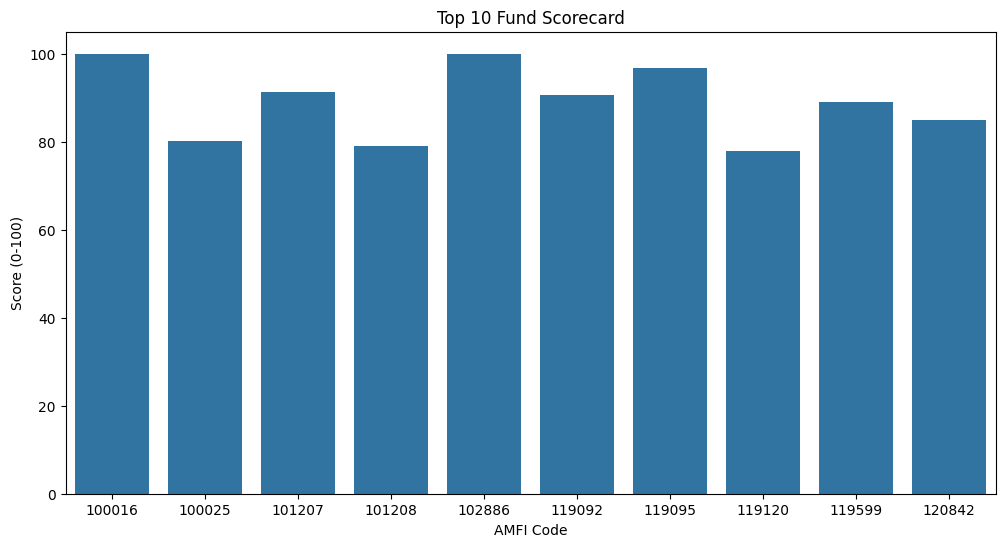

In [42]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_scorecard,
    x='amfi_code',
    y='fund_score'
)

plt.title("Top 10 Fund Scorecard")
plt.xlabel("AMFI Code")
plt.ylabel("Score (0-100)")

plt.show()

In [43]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved successfully")

fund_scorecard.csv saved successfully


### Finding 7

The composite fund scorecard combines returns, risk-adjusted performance, alpha generation, expenses, and drawdown characteristics to identify the most balanced mutual fund schemes.

In [44]:
top5_funds = scorecard.sort_values(
    by='fund_score',
    ascending=False
).head(5)

top5_codes = top5_funds['amfi_code'].tolist()

print(top5_codes)

[102886, 100016, 119095, 101207, 119092]


In [45]:
top5_nav = nav_history[
    nav_history['amfi_code'].isin(top5_codes)
].copy()

top5_nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [46]:
benchmark_compare = benchmark[
    benchmark['index_name'].isin(
        ['NIFTY50','NIFTY100']
    )
].copy()

benchmark_compare.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [47]:
benchmark_compare = benchmark_compare.sort_values(
    ['index_name','date']
)

benchmark_compare['benchmark_return'] = (
    benchmark_compare.groupby('index_name')
    ['close_value']
    .pct_change()
)

In [48]:
tracking_error_results = []

for fund in top5_codes:

    fund_returns = nav_history[
        nav_history['amfi_code'] == fund
    ][['date','daily_return']]

    nifty100_returns = benchmark_compare[
        benchmark_compare['index_name'] == 'NIFTY100'
    ][['date','benchmark_return']]

    merged = pd.merge(
        fund_returns,
        nifty100_returns,
        on='date'
    ).dropna()

    tracking_error = (
        (merged['daily_return']
         - merged['benchmark_return'])
        .std()
        * np.sqrt(252)
    )

    tracking_error_results.append([
        fund,
        round(tracking_error,4)
    ])

tracking_error_df = pd.DataFrame(
    tracking_error_results,
    columns=[
        'amfi_code',
        'tracking_error'
    ]
)

tracking_error_df

,amfi_code,tracking_error
0,102886,0.2256
1,100016,0.1993
2,119095,0.2858
3,101207,0.2921
4,119092,0.1891


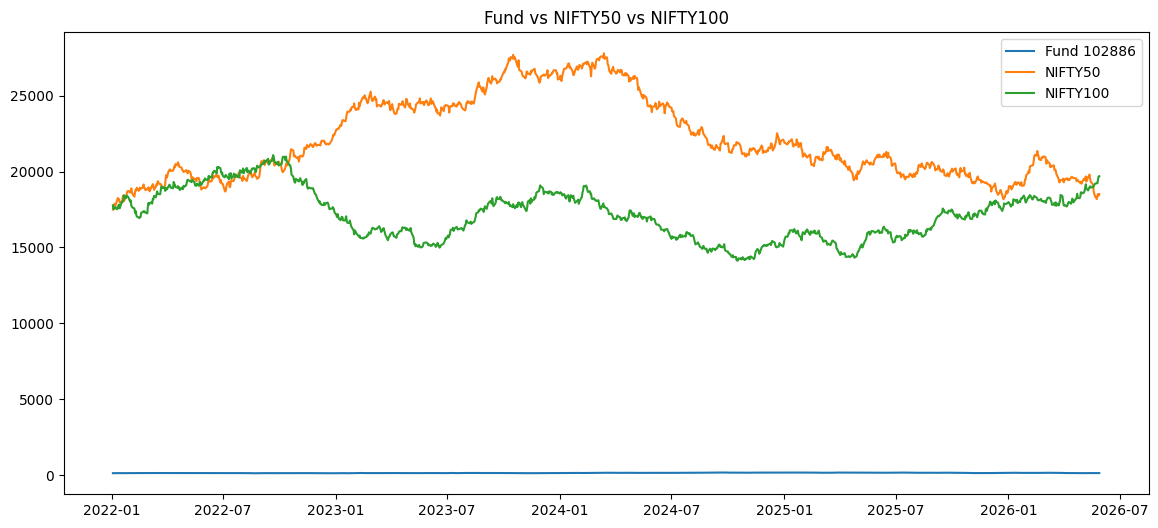

In [49]:
sample_fund = top5_codes[0]

fund_data = nav_history[
    nav_history['amfi_code'] == sample_fund
].copy()

plt.figure(figsize=(14,6))

plt.plot(
    fund_data['date'],
    fund_data['nav'],
    label=f'Fund {sample_fund}'
)

nifty50 = benchmark[
    benchmark['index_name'] == 'NIFTY50'
]

plt.plot(
    nifty50['date'],
    nifty50['close_value'],
    label='NIFTY50'
)

nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
]

plt.plot(
    nifty100['date'],
    nifty100['close_value'],
    label='NIFTY100'
)

plt.legend()

plt.title(
    "Fund vs NIFTY50 vs NIFTY100"
)

plt.show()

In [50]:
tracking_error_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

print("tracking_error.csv saved")

tracking_error.csv saved


In [51]:
plt.savefig(
    "../reports/benchmark_comparison.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

### Finding 8

Benchmark comparison shows how closely top-performing funds track market indices. Lower tracking error indicates benchmark-like performance, while higher tracking error suggests active management and differentiated investment strategies.